In [40]:
# Import Libraries

import pandas as pd              
import numpy as np               
import matplotlib.pyplot as plt  
import seaborn as sns            

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')  # Hides minor warnings to keep output tidy

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [41]:
import os
print(os.getcwd())

C:\Users\Ruweida Ali\FINAL PROJECT


In [42]:
# This installs the xlrd library which pandas needs to read .xls files
# The ! means "run this as a terminal command from inside Jupyter"

!pip install xlrd

In [43]:
# Load the Dataset

df = pd.read_excel(r'INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("Data loaded successfully!")

Dataset shape: 1200 rows × 28 columns
Data loaded successfully!


In [44]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


## Dataset Shape & Basic Information

Here we check the size of our dataset and the data type of each column.
This tells us how many employees we have and what kind of data each 
column contains — numbers, text, etc.

In [45]:
# .shape tells us rows × columns
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()

# .info() gives us column names, data types and null counts all at once
df.info()

Dataset Shape: 1200 rows × 28 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 no

##  Checking for Missing Values

Missing values can break machine learning models. Here we explicitly 
check every column for missing values and visualise them. A good 
dataset has zero missing values — let's confirm ours does!

In [46]:
# Check for missing values in every column
print("Missing Values Per Column:")
print("="*40)
print(df.isnull().sum())
print()
print(f"Total missing values in entire dataset: {df.isnull().sum().sum()}")


Missing Values Per Column:
EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

Total m

##  Statistical Summary

Here we generate descriptive statistics for all numerical columns.
This tells us the average, minimum, maximum and spread of each feature
— helping us understand the range of values we are working with.

In [47]:
# .describe() gives us key statistics for every numerical column
# count    = number of values
# mean     = average
# std      = standard deviation (how spread out the values are)
# min/max  = smallest and largest values
# 25%/50%/75% = quartiles (how data is distributed)

df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


##  Target Variable Distribution — Performance Rating

PerformanceRating is what we are trying to predict — it is our target variable.
Here we check how many employees fall into each rating category.
Understanding this distribution is critical before building any model.

Performance Rating Distribution:
2    194
3    874
4    132
Name: PerformanceRating, dtype: int64

As Percentages:
2    16.17
3    72.83
4    11.00
Name: PerformanceRating, dtype: float64



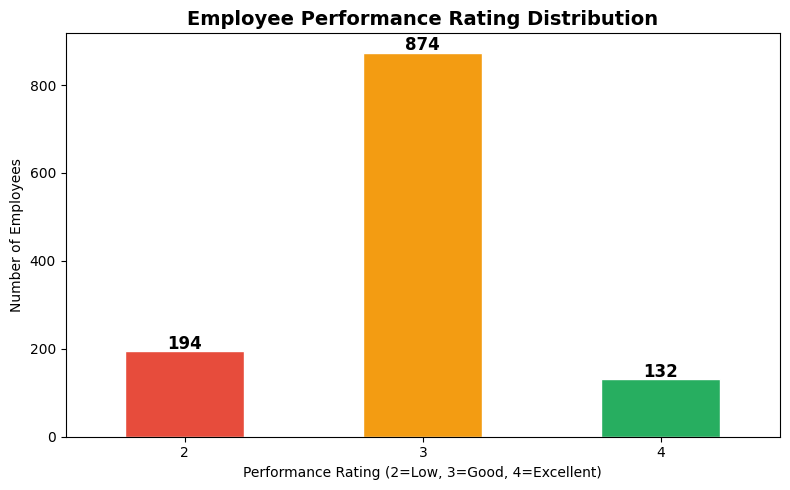

In [48]:
# Count how many employees fall in each performance rating category
print("Performance Rating Distribution:")
print("="*40)
print(df['PerformanceRating'].value_counts().sort_index())
print()

# Show as percentages too
print("As Percentages:")
print("="*40)
print((df['PerformanceRating'].value_counts(normalize=True).sort_index() * 100).round(2))
print()

# Visualise it as a bar chart
plt.figure(figsize=(8, 5))
ax = df['PerformanceRating'].value_counts().sort_index().plot(
    kind='bar',
    color=['#e74c3c', '#f39c12', '#27ae60'],
    edgecolor='white',
    width=0.5
)
plt.title('Employee Performance Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Performance Rating (2=Low, 3=Good, 4=Excellent)')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2, p.get_height() + 5),
                ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

##  Department-wise Performance Analysis

Here we look at how each department is performing.
We calculate the average performance rating per department
and visualise it in a simple bar chart.

In [49]:
#  Calculate average performance rating per department
dept_avg = df.groupby('EmpDepartment')['PerformanceRating'].mean().round(2)
print("Average Performance Rating by Department:")
print(dept_avg.sort_values())

Average Performance Rating by Department:
EmpDepartment
Finance                   2.78
Sales                     2.86
Research & Development    2.92
Human Resources           2.93
Data Science              3.05
Development               3.09
Name: PerformanceRating, dtype: float64


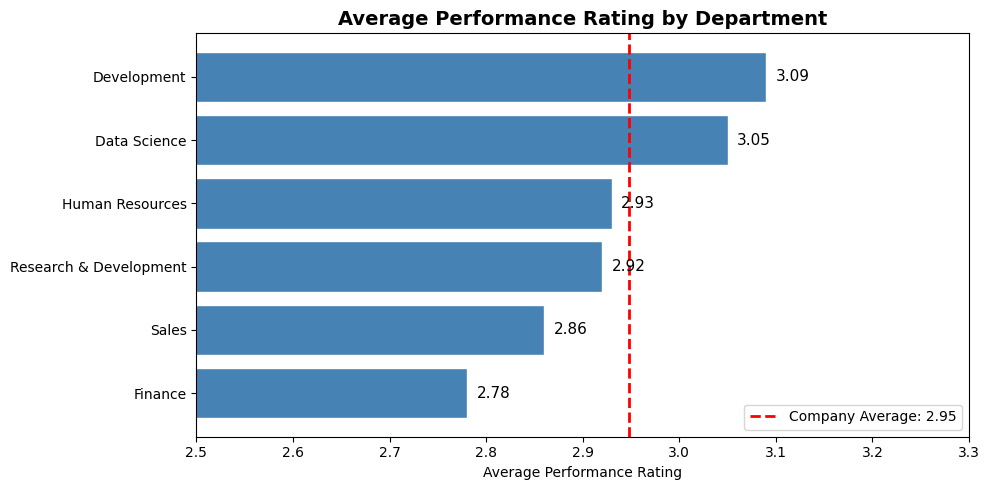

In [50]:
#  Visualise average performance rating per department

dept_avg_sorted = dept_avg.sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(dept_avg_sorted.index, dept_avg_sorted.values, 
                color='steelblue', edgecolor='white')

# Add a vertical line showing the company average
plt.axvline(x=df['PerformanceRating'].mean(), 
            color='red', linestyle='--', linewidth=2,
            label=f'Company Average: {df["PerformanceRating"].mean():.2f}')

# Add value labels on each bar
for bar, val in zip(bars, dept_avg_sorted.values):
    plt.text(bar.get_width() + 0.01, 
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11)

plt.title('Average Performance Rating by Department', 
          fontsize=14, fontweight='bold')
plt.xlabel('Average Performance Rating')
plt.xlim(2.5, 3.3)
plt.legend()
plt.tight_layout()
plt.show()

##  Label Encoding — Converting Text to Numbers

Machine learning models only understand numbers, not text.
So we convert all text columns (like Gender, Department, Job Role)
into numbers using Label Encoding.
For example: Male = 1, Female = 0

In [51]:
# STEP 1 — Make a copy of our dataset so we don't damage the original
df_encoded = df.copy()

# STEP 2 — List all the text columns we need to convert
text_columns = ['Gender', 'EducationBackground', 'MaritalStatus', 
                'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 
                'OverTime', 'Attrition']

# STEP 3 — Apply Label Encoding to each text column
le = LabelEncoder()

for column in text_columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

print("Label Encoding Complete!")
print()
print("Sample — Gender column before and after:")
print(f"Before: {df['Gender'].unique()}")
print(f"After : {df_encoded['Gender'].unique()}")

Label Encoding Complete!

Sample — Gender column before and after:
Before: ['Male' 'Female']
After : [1 0]


In [52]:
# Drop EmpNumber — it's just an ID tag, not useful for prediction

df_encoded = df_encoded.drop('EmpNumber', axis=1)

print("EmpNumber column removed!")
print(f"Dataset now has {df_encoded.shape[1]} columns")

EmpNumber column removed!
Dataset now has 27 columns


In [53]:
# Check data types of all columns to confirm encoding worked
print("Data Types After Encoding:")
print("="*40)
print(df_encoded.dtypes)

Data Types After Encoding:
Age                             int64
Gender                          int32
EducationBackground             int32
MaritalStatus                   int32
EmpDepartment                   int32
EmpJobRole                      int32
BusinessTravelFrequency         int32
DistanceFromHome                int64
EmpEducationLevel               int64
EmpEnvironmentSatisfaction      int64
EmpHourlyRate                   int64
EmpJobInvolvement               int64
EmpJobLevel                     int64
EmpJobSatisfaction              int64
NumCompaniesWorked              int64
OverTime                        int32
EmpLastSalaryHikePercent        int64
EmpRelationshipSatisfaction     int64
TotalWorkExperienceInYears      int64
TrainingTimesLastYear           int64
EmpWorkLifeBalance              int64
ExperienceYearsAtThisCompany    int64
ExperienceYearsInCurrentRole    int64
YearsSinceLastPromotion         int64
YearsWithCurrManager            int64
Attrition              

##  Exploratory Data Analysis (EDA)

Before building our model we explore relationships between 
features and performance rating visually.
This helps us understand our data deeply and guides our 
feature selection decisions.

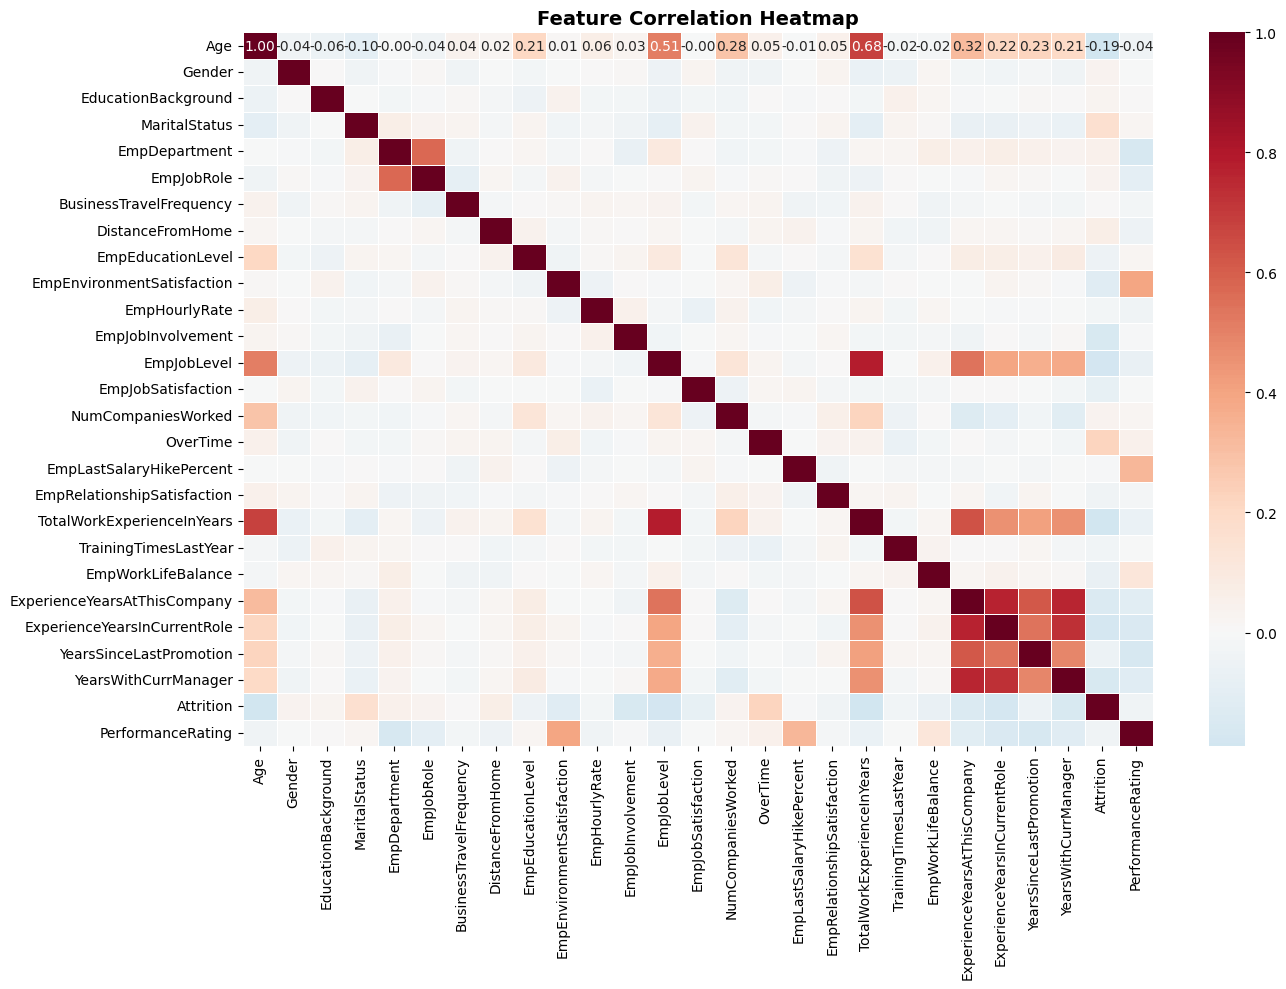

In [54]:
# CORRELATION HEATMAP
# Shows how strongly each feature relates to every other feature
# Values close to 1 or -1 = strong relationship
# Values close to 0 = weak relationship

plt.figure(figsize=(14, 10))
correlation = df_encoded.corr()

sns.heatmap(correlation, 
            annot=True,          # show numbers inside boxes
            fmt='.2f',           # round to 2 decimal places
            cmap='RdBu_r',       # red = positive, blue = negative
            center=0,            # white = no correlation
            linewidths=0.5)      # lines between boxes

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Correlation Heatmap — Key Findings

The heatmap reveals the following relationships with PerformanceRating:

**Strongest Positive Relationships:**
- EmpLastSalaryHikePercent — higher salary hike = better performance
- EmpEnvironmentSatisfaction — happier workplace = better performance

**Strongest Negative Relationship:**
- YearsSinceLastPromotion — longer without promotion = worse performance

**No Impact on Performance:**
- Age, DistanceFromHome, Gender and EmpHourlyRate show 
  almost zero correlation with performance

These findings will be confirmed in our Feature Importance step.

##  Key Feature Relationships with Performance Rating

Here we visually explore how our top features relate 
to performance rating using boxplots.
A boxplot shows us the spread and average of values 
for each performance rating group.

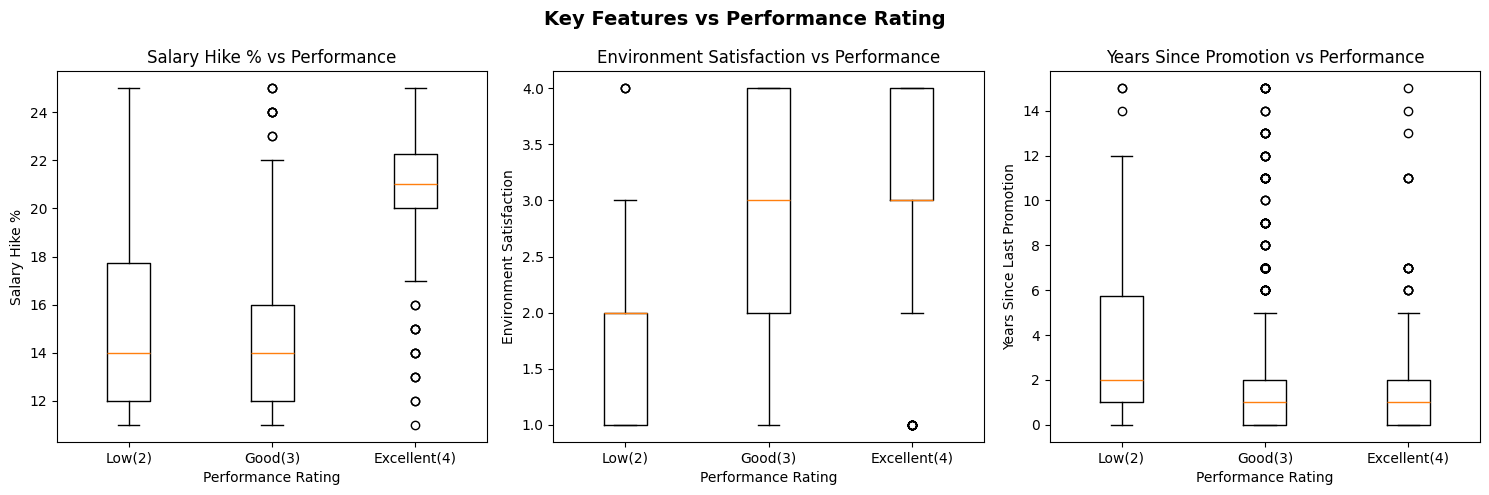

In [55]:
# Create 3 boxplots for our top 3 expected features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Key Features vs Performance Rating', 
             fontsize=14, fontweight='bold')

# Chart 1 — Salary Hike vs Performance
axes[0].boxplot([df[df['PerformanceRating']==2]['EmpLastSalaryHikePercent'],
                 df[df['PerformanceRating']==3]['EmpLastSalaryHikePercent'],
                 df[df['PerformanceRating']==4]['EmpLastSalaryHikePercent']],
                 labels=['Low(2)','Good(3)','Excellent(4)'])
axes[0].set_title('Salary Hike % vs Performance')
axes[0].set_ylabel('Salary Hike %')
axes[0].set_xlabel('Performance Rating')

# Chart 2 — Environment Satisfaction vs Performance
axes[1].boxplot([df[df['PerformanceRating']==2]['EmpEnvironmentSatisfaction'],
                 df[df['PerformanceRating']==3]['EmpEnvironmentSatisfaction'],
                 df[df['PerformanceRating']==4]['EmpEnvironmentSatisfaction']],
                 labels=['Low(2)','Good(3)','Excellent(4)'])
axes[1].set_title('Environment Satisfaction vs Performance')
axes[1].set_ylabel('Environment Satisfaction')
axes[1].set_xlabel('Performance Rating')

# Chart 3 — Years Since Last Promotion vs Performance
axes[2].boxplot([df[df['PerformanceRating']==2]['YearsSinceLastPromotion'],
                 df[df['PerformanceRating']==3]['YearsSinceLastPromotion'],
                 df[df['PerformanceRating']==4]['YearsSinceLastPromotion']],
                 labels=['Low(2)','Good(3)','Excellent(4)'])
axes[2].set_title('Years Since Promotion vs Performance')
axes[2].set_ylabel('Years Since Last Promotion')
axes[2].set_xlabel('Performance Rating')

plt.tight_layout()
plt.show()

##  Boxplot Results — Key Findings

**Chart 1 — Salary Hike % vs Performance:**
- Excellent performers (4) clearly receive higher salary hikes
  with a median around 21%
- Low and Good performers share a similar median of 14%
- This confirms salary hike is our strongest performance driver

**Chart 2 — Environment Satisfaction vs Performance:**
- Good and Excellent performers show higher environment 
  satisfaction scores than Low performers
- Low performers have a median satisfaction of only 2
- A happy workplace environment clearly leads to better performance

**Chart 3 — Years Since Last Promotion vs Performance:**
- Low performers have waited longer since their last promotion
  with a higher median than Good and Excellent performers
- Good and Excellent performers have a median of just 1 year
- Promotion stagnation clearly hurts performance

**Overall Conclusion:**
All three charts confirm our heatmap findings — Salary Hike,
Environment Satisfaction and Promotion Frequency are the 
key drivers of employee performance at INX Future Inc.

##  Distribution of Key Numeric Features

Here I look at how the key numeric features are distributed 
across the dataset. This helps us understand the spread of 
values and identify any skewness in the data.
Skewness means the data is not evenly spread and is 
leaning more towards one side.

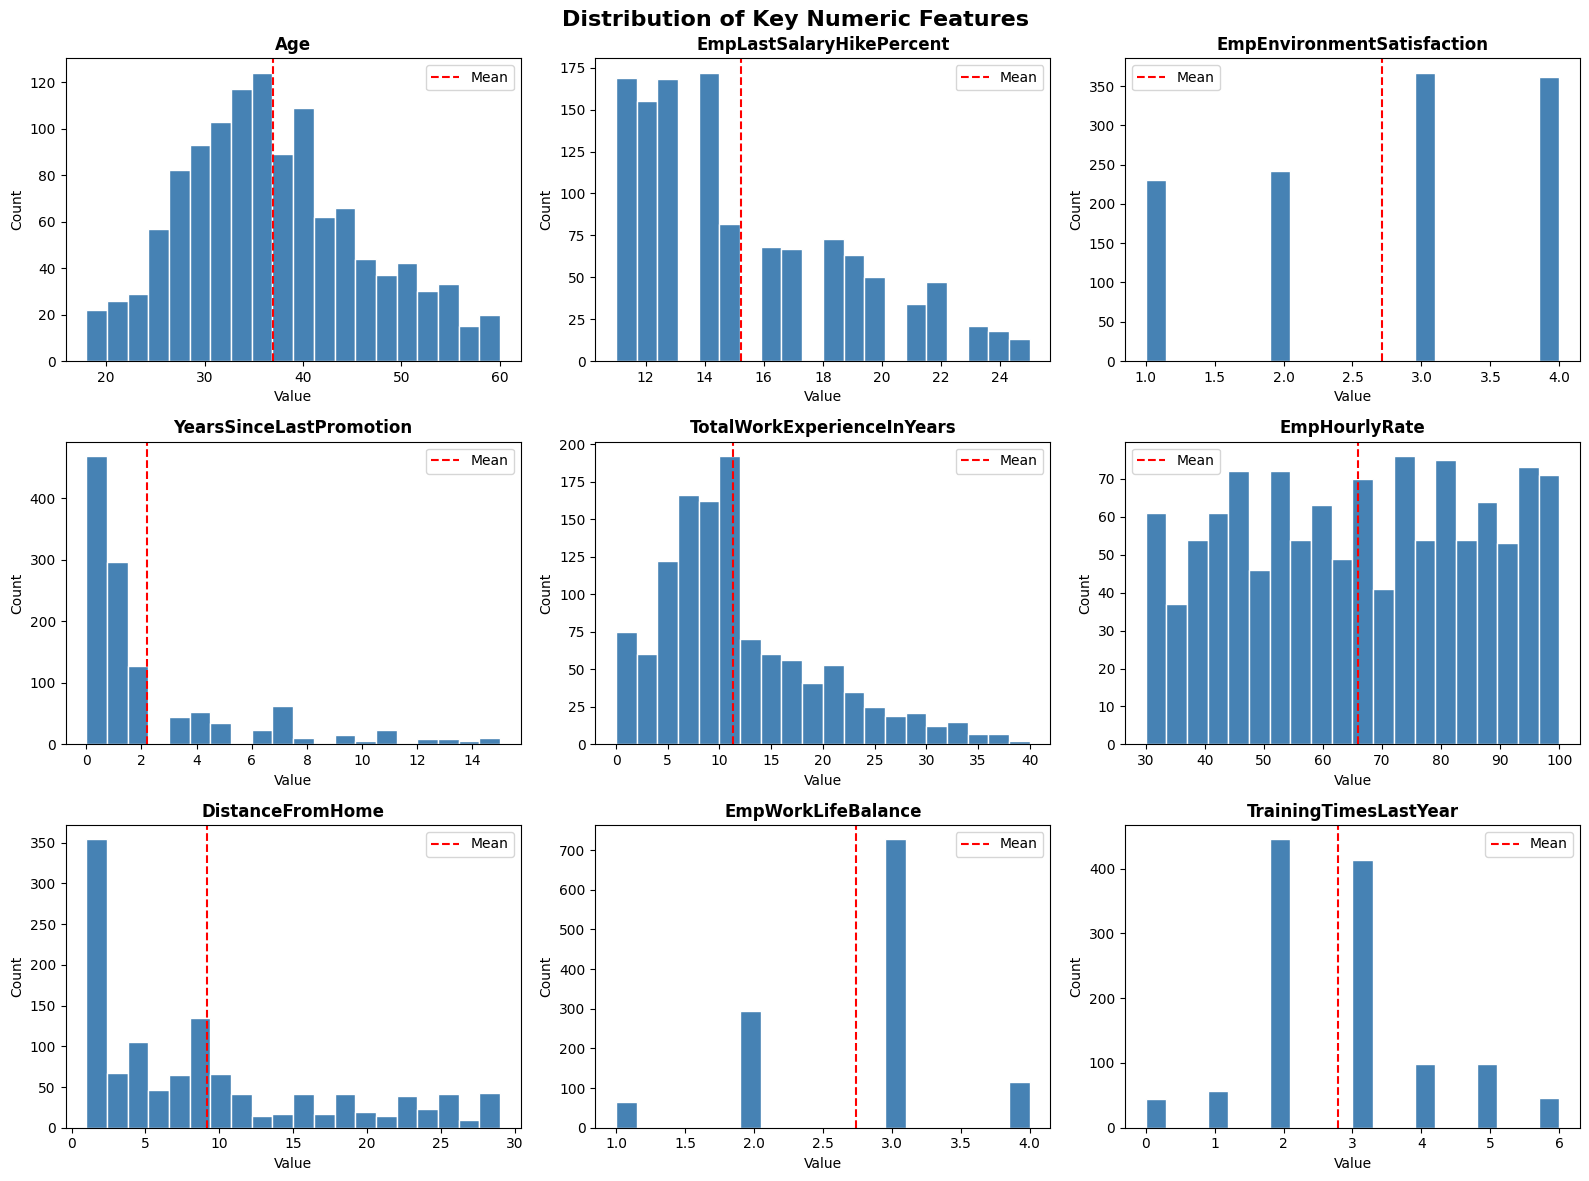

In [56]:
# Distribution plots for key numeric features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribution of Key Numeric Features', 
             fontsize=16, fontweight='bold')

features_to_plot = [
    'Age', 
    'EmpLastSalaryHikePercent',
    'EmpEnvironmentSatisfaction',
    'YearsSinceLastPromotion',
    'TotalWorkExperienceInYears',
    'EmpHourlyRate',
    'DistanceFromHome',
    'EmpWorkLifeBalance',
    'TrainingTimesLastYear'
]

for i, feature in enumerate(features_to_plot):
    row = i // 3
    col = i % 3
    axes[row, col].hist(df[feature], bins=20, 
                        color='steelblue', edgecolor='white')
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Count')
    axes[row, col].axvline(df[feature].mean(), 
                           color='red', linestyle='--', 
                           linewidth=1.5, label='Mean')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

##  Distribution Results

Key findings from the distribution plots:
- Age is normally distributed with most employees aged 30 to 45
- YearsSinceLastPromotion is heavily skewed showing most employees 
  were recently promoted but some waited up to 15 years
- EmpLastSalaryHikePercent shows most employees got 11 to 15% hike
- DistanceFromHome shows most employees live close to work
- EmpWorkLifeBalance shows most employees rated it 3 out of 4
- TrainingTimesLastYear shows most employees got 2 to 3 sessions

## Overtime vs Performance Rating

Here I examine how working overtime relates to 
employee performance across the company.

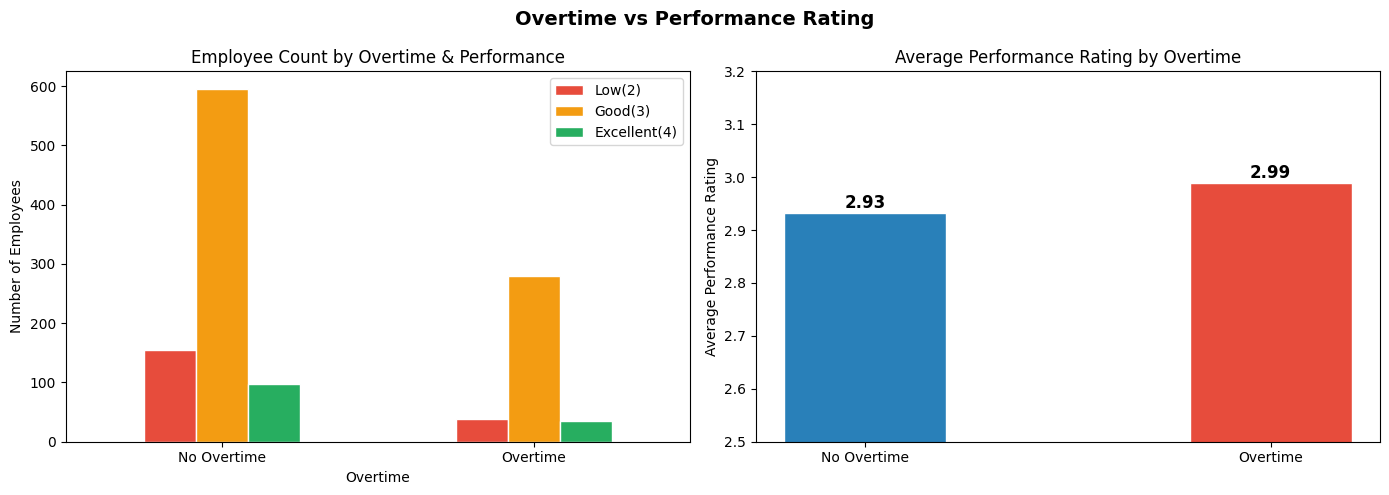

Average Performance Rating:
No Overtime : 2.93
Overtime    : 2.99


In [57]:
# Overtime vs Performance Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overtime vs Performance Rating', 
             fontsize=14, fontweight='bold')

# Chart 1 — Count of employees by overtime and performance
overtime_perf = df.groupby(['OverTime', 'PerformanceRating']).size().unstack()
overtime_perf.plot(kind='bar', ax=axes[0],
                   color=['#e74c3c', '#f39c12', '#27ae60'],
                   edgecolor='white', width=0.5)
axes[0].set_title('Employee Count by Overtime & Performance')
axes[0].set_xlabel('Overtime')
axes[0].set_ylabel('Number of Employees')
axes[0].set_xticklabels(['No Overtime', 'Overtime'], rotation=0)
axes[0].legend(['Low(2)', 'Good(3)', 'Excellent(4)'])

# Chart 2 — Average performance rating by overtime
overtime_avg = df.groupby('OverTime')['PerformanceRating'].mean()
axes[1].bar(['No Overtime', 'Overtime'], overtime_avg.values,
            color=['#2980b9', '#e74c3c'], edgecolor='white', width=0.4)
axes[1].set_title('Average Performance Rating by Overtime')
axes[1].set_ylabel('Average Performance Rating')
axes[1].set_ylim(2.5, 3.2)

# Add value labels
for i, val in enumerate(overtime_avg.values):
    axes[1].text(i, val + 0.01, f'{val:.2f}', 
                ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the numbers
print("Average Performance Rating:")
print(f"No Overtime : {overtime_avg['No']:.2f}")
print(f"Overtime    : {overtime_avg['Yes']:.2f}")

##  Overtime vs Performance Results

Interestingly employees who work overtime have a slightly 
higher average rating of 2.99 compared to 2.93 for those 
who don't. However the difference is very small.

More importantly the majority of low performers are found 
in the no overtime group simply because there are more 
employees in that group overall.

Overtime alone is not a strong driver of performance 
which is confirmed by its low feature importance score.

##  Attrition vs Performance Rating

Here I examine whether employees who left the company 
were more likely to be low performers.

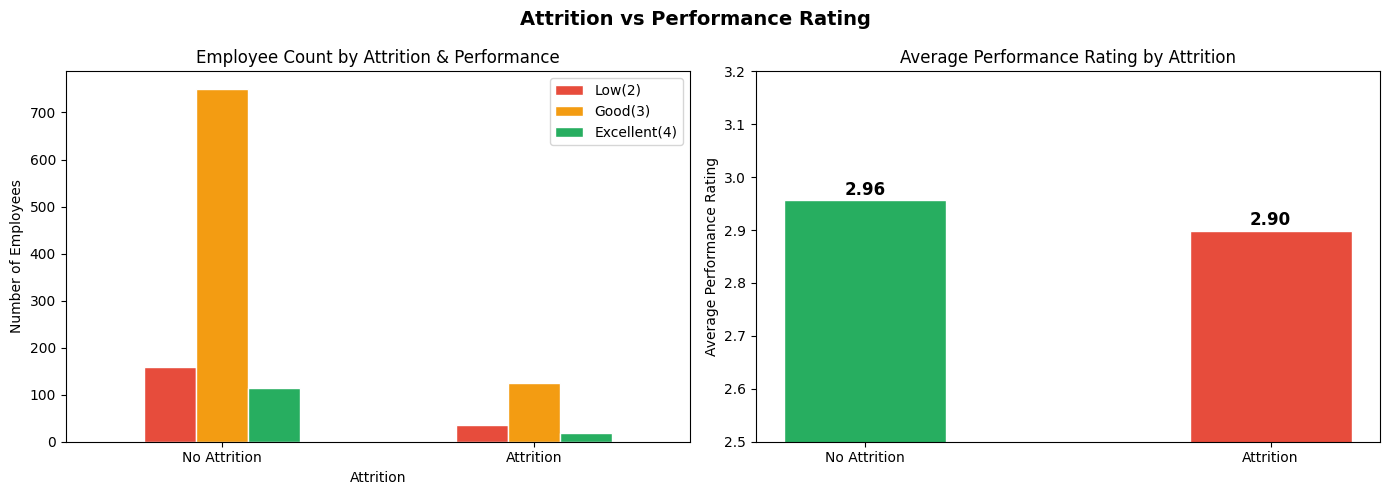

Average Performance Rating:
No Attrition : 2.96
Attrition    : 2.90


In [58]:
# Attrition vs Performance Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attrition vs Performance Rating', 
             fontsize=14, fontweight='bold')

# Chart 1 — Count
attrition_perf = df.groupby(['Attrition', 'PerformanceRating']).size().unstack()
attrition_perf.plot(kind='bar', ax=axes[0],
                    color=['#e74c3c', '#f39c12', '#27ae60'],
                    edgecolor='white', width=0.5)
axes[0].set_title('Employee Count by Attrition & Performance')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
axes[0].set_xticklabels(['No Attrition', 'Attrition'], rotation=0)
axes[0].legend(['Low(2)', 'Good(3)', 'Excellent(4)'])

# Chart 2 — Average performance by attrition
attrition_avg = df.groupby('Attrition')['PerformanceRating'].mean()
axes[1].bar(['No Attrition', 'Attrition'], attrition_avg.values,
            color=['#27ae60', '#e74c3c'], edgecolor='white', width=0.4)
axes[1].set_title('Average Performance Rating by Attrition')
axes[1].set_ylabel('Average Performance Rating')
axes[1].set_ylim(2.5, 3.2)

for i, val in enumerate(attrition_avg.values):
    axes[1].text(i, val + 0.01, f'{val:.2f}',
                ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Average Performance Rating:")
print(f"No Attrition : {attrition_avg['No']:.2f}")
print(f"Attrition    : {attrition_avg['Yes']:.2f}")

##  Remaining EDA Charts

Here I examine how Gender, Education Background, Business 
Travel, Marital Status and Job Role relate to performance.

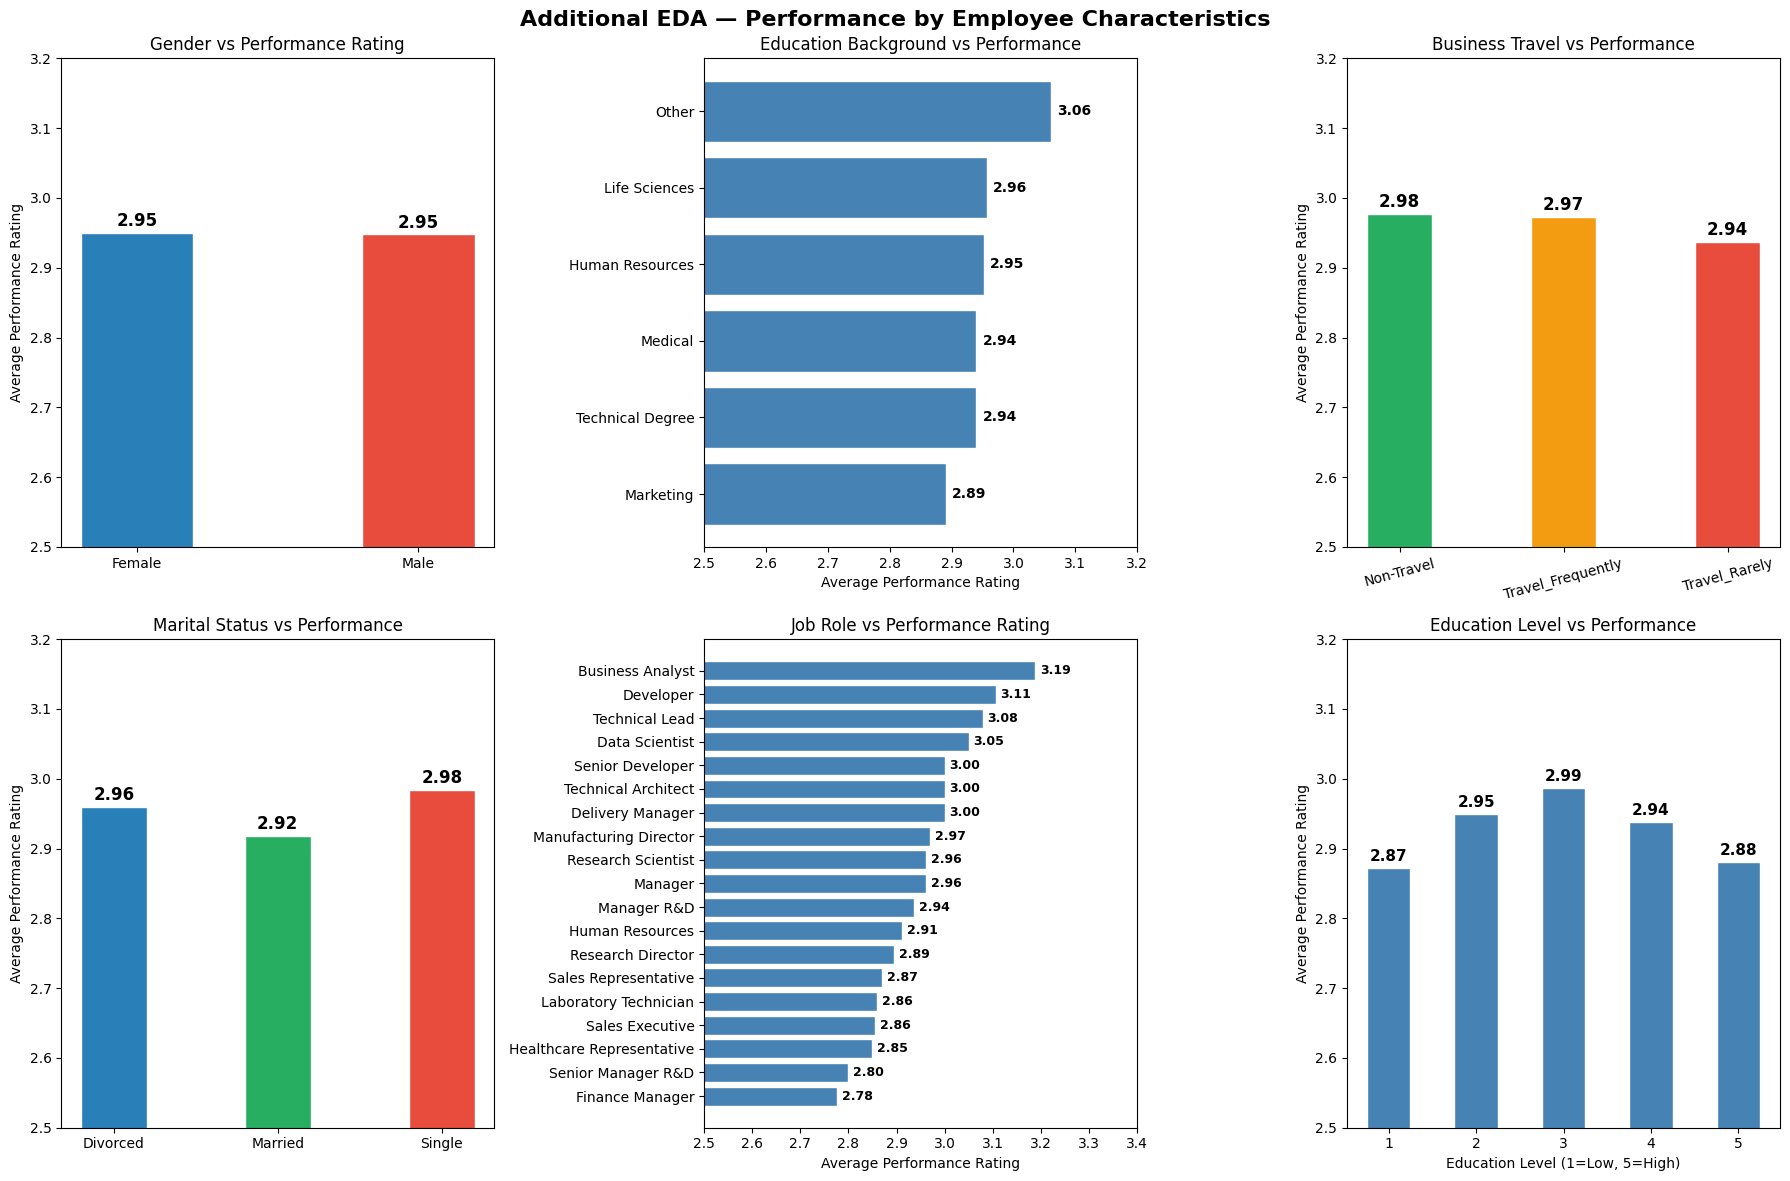

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Additional EDA — Performance by Employee Characteristics',
             fontsize=16, fontweight='bold')

# Chart 1 — Gender vs Performance
gender_avg = df.groupby('Gender')['PerformanceRating'].mean()
axes[0,0].bar(gender_avg.index, gender_avg.values,
              color=['#2980b9', '#e74c3c'], edgecolor='white', width=0.4)
axes[0,0].set_title('Gender vs Performance Rating')
axes[0,0].set_ylabel('Average Performance Rating')
axes[0,0].set_ylim(2.5, 3.2)
for i, val in enumerate(gender_avg.values):
    axes[0,0].text(i, val + 0.01, f'{val:.2f}',
                   ha='center', fontsize=12, fontweight='bold')

# Chart 2 — Education Background vs Performance
edu_avg = df.groupby('EducationBackground')['PerformanceRating'].mean().sort_values()
axes[0,1].barh(edu_avg.index, edu_avg.values, color='steelblue', edgecolor='white')
axes[0,1].set_title('Education Background vs Performance')
axes[0,1].set_xlabel('Average Performance Rating')
axes[0,1].set_xlim(2.5, 3.2)
for i, val in enumerate(edu_avg.values):
    axes[0,1].text(val + 0.01, i, f'{val:.2f}',
                   va='center', fontsize=10, fontweight='bold')

# Chart 3 — Business Travel vs Performance
travel_avg = df.groupby('BusinessTravelFrequency')['PerformanceRating'].mean()
axes[0,2].bar(travel_avg.index, travel_avg.values,
              color=['#27ae60','#f39c12','#e74c3c'], edgecolor='white', width=0.4)
axes[0,2].set_title('Business Travel vs Performance')
axes[0,2].set_ylabel('Average Performance Rating')
axes[0,2].set_ylim(2.5, 3.2)
axes[0,2].set_xticklabels(travel_avg.index, rotation=15)
for i, val in enumerate(travel_avg.values):
    axes[0,2].text(i, val + 0.01, f'{val:.2f}',
                   ha='center', fontsize=12, fontweight='bold')

# Chart 4 — Marital Status vs Performance
marital_avg = df.groupby('MaritalStatus')['PerformanceRating'].mean()
axes[1,0].bar(marital_avg.index, marital_avg.values,
              color=['#2980b9','#27ae60','#e74c3c'], edgecolor='white', width=0.4)
axes[1,0].set_title('Marital Status vs Performance')
axes[1,0].set_ylabel('Average Performance Rating')
axes[1,0].set_ylim(2.5, 3.2)
for i, val in enumerate(marital_avg.values):
    axes[1,0].text(i, val + 0.01, f'{val:.2f}',
                   ha='center', fontsize=12, fontweight='bold')

# Chart 5 — Top 10 Job Roles vs Performance
role_avg = df.groupby('EmpJobRole')['PerformanceRating'].mean().sort_values()
axes[1,1].barh(role_avg.index, role_avg.values,
               color='steelblue', edgecolor='white')
axes[1,1].set_title('Job Role vs Performance Rating')
axes[1,1].set_xlabel('Average Performance Rating')
axes[1,1].set_xlim(2.5, 3.4)
for i, val in enumerate(role_avg.values):
    axes[1,1].text(val + 0.01, i, f'{val:.2f}',
                   va='center', fontsize=9, fontweight='bold')

# Chart 6 — Education Level vs Performance
edulevel_avg = df.groupby('EmpEducationLevel')['PerformanceRating'].mean()
axes[1,2].bar(edulevel_avg.index, edulevel_avg.values,
              color='steelblue', edgecolor='white', width=0.5)
axes[1,2].set_title('Education Level vs Performance')
axes[1,2].set_xlabel('Education Level (1=Low, 5=High)')
axes[1,2].set_ylabel('Average Performance Rating')
axes[1,2].set_ylim(2.5, 3.2)
for i, val in enumerate(edulevel_avg.values):
    axes[1,2].text(edulevel_avg.index[i], val + 0.01, f'{val:.2f}',
                   ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Additional EDA Results

Gender — both male and female employees have identical 
average ratings of 2.95 showing no gender bias in performance.

Education Background — employees with Other backgrounds 
scored highest at 3.06 while Marketing scored lowest at 2.89.

Business Travel — non travelling employees perform slightly 
better at 2.98 compared to frequent travellers at 2.97.

Marital Status — single employees perform best at 2.98 
while married employees score lowest at 2.92.

Job Role — Business Analysts perform best at 3.19 while 
Finance Managers perform worst at 2.78 which aligns with 
our finding that Finance is the weakest department.

Education Level — employees with education level 3 perform 
best at 2.99 while level 1 performs worst at 2.87 suggesting 
that mid level education is optimal for performance.

## Outlier Detection

Outliers are extreme values that sit far outside the normal 
range of data. They can affect model performance and skew 
our analysis. Here I use the IQR method to detect and 
understand outliers in our key numeric features.

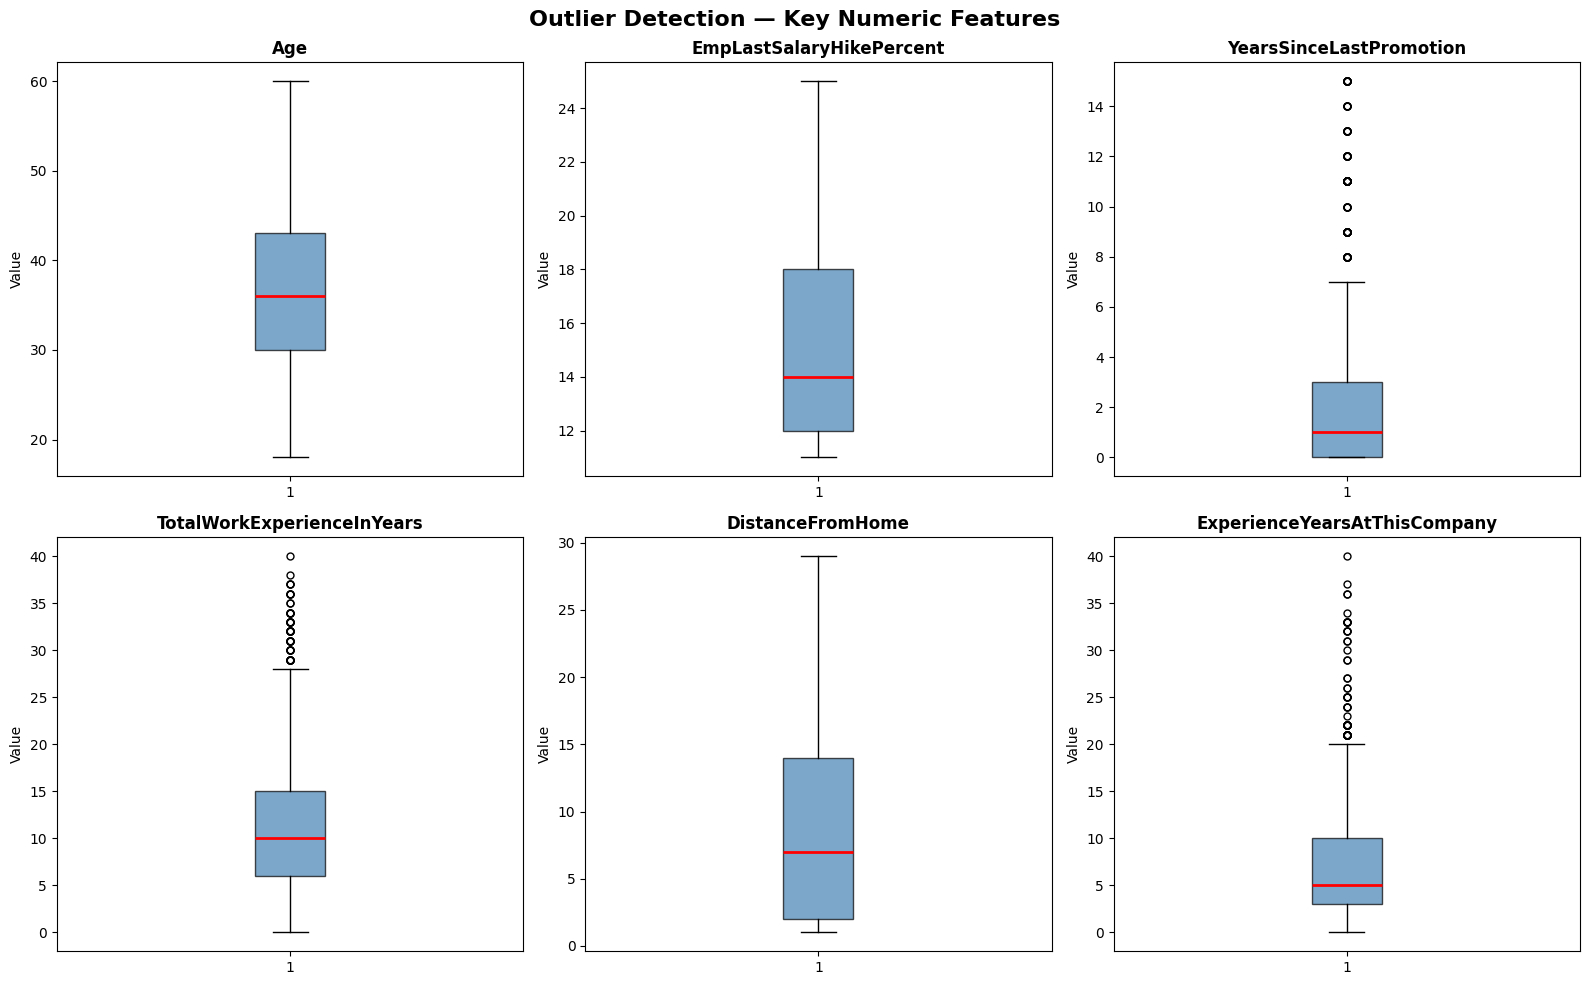

OUTLIER COUNT PER FEATURE (IQR Method):
Age                                : 0 outliers
EmpLastSalaryHikePercent           : 0 outliers
YearsSinceLastPromotion            : 88 outliers
TotalWorkExperienceInYears         : 51 outliers
DistanceFromHome                   : 0 outliers
ExperienceYearsAtThisCompany       : 56 outliers


In [60]:
# Outlier detection using boxplots for key numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Outlier Detection — Key Numeric Features',
             fontsize=16, fontweight='bold')

features_outlier = [
    'Age',
    'EmpLastSalaryHikePercent',
    'YearsSinceLastPromotion',
    'TotalWorkExperienceInYears',
    'DistanceFromHome',
    'ExperienceYearsAtThisCompany'
]

for i, feature in enumerate(features_outlier):
    row = i // 3
    col = i % 3
    axes[row, col].boxplot(df[feature], patch_artist=True,
                           boxprops=dict(facecolor='steelblue', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           flierprops=dict(marker='o', color='red', 
                                          markersize=5))
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_ylabel('Value')

plt.tight_layout()
plt.show()

# IQR method to count outliers in each feature
print("OUTLIER COUNT PER FEATURE (IQR Method):")
print("="*45)
for feature in features_outlier:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    print(f"{feature:35s}: {len(outliers)} outliers")

##  Outlier Detection Results

YearsSinceLastPromotion has 88 outliers, TotalWorkExperienceInYears 
has 51 and ExperienceYearsAtThisCompany has 56 representing employees 
who have been stagnant or highly experienced for unusually long periods.

Age, EmpLastSalaryHikePercent and DistanceFromHome have zero outliers.

Since Random Forest is not sensitive to outliers we keep all values 
in the dataset to avoid losing important employee information.

## Separating Features and Target Variable

Here I separate the data into inputs and output.
X contains all the features the model will learn from.
y contains only the PerformanceRating which is what 
the model will predict.

In [61]:
# X = everything except PerformanceRating (our inputs)
# y = PerformanceRating only (what we want to predict)

X = df_encoded.drop('PerformanceRating', axis=1)
y = df_encoded['PerformanceRating']

print(f"Input features  (X): {X.shape[1]} columns")
print(f"Target variable (y): PerformanceRating")
print()
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Input features  (X): 26 columns
Target variable (y): PerformanceRating

X shape: (1200, 26)
y shape: (1200,)


##  Principal Component Analysis (PCA) Check

The guidelines ask whether a technique like PCA was used. PCA is a method 
that combines many features into a smaller number of components while 
keeping as much information as possible. Here I run PCA just to check how 
many components would be needed to capture most of the variation in the data, 
and then decide whether it is worth using.

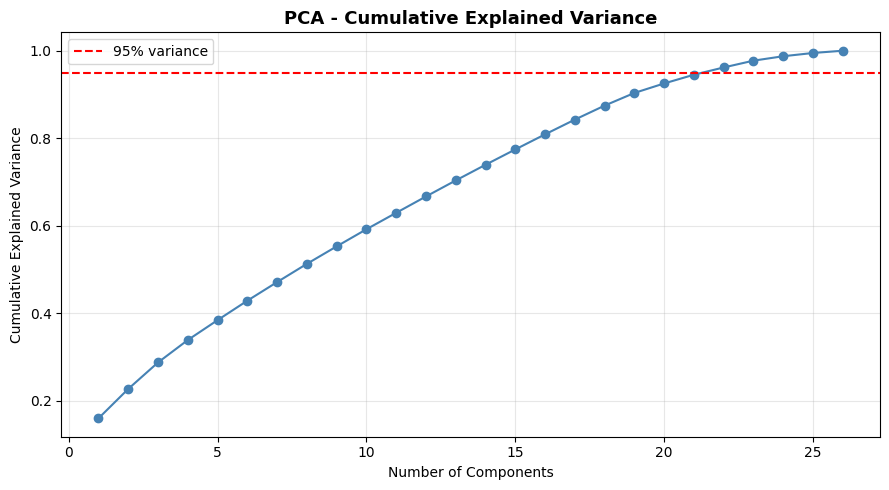

Components needed to keep 95% of the information: 22 out of 26


In [62]:
# Run PCA to see how many components are needed to explain the variance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA needs scaled data to work properly
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

# Fit PCA with all components
pca = PCA()
pca.fit(X_scaled_pca)

# Calculate cumulative explained variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()

# Plot how variance builds up as we add components
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.title('PCA - Cumulative Explained Variance', fontsize=13, fontweight='bold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find how many components are needed for 95% of the variance
components_needed = (cumulative_variance < 0.95).sum() + 1
print(f"Components needed to keep 95% of the information: {components_needed} out of {X.shape[1]}")

##  PCA Result and Decision

PCA needed 22 of the 26 components to keep 95% of the information which is 
barely any reduction. Since it would not simplify the data much and would 
replace clear named features with abstract components, I chose not to use PCA 
and kept the original features so the results stay meaningful and easy to act on.

## Train Test Split

Here I split the dataset into 80% training and 20% testing.
The training set is what the model learns from and the testing 
set is used to evaluate how well it performs on new unseen data.
I used stratify=y to make sure all three performance rating 
categories are equally represented in both sets.

In [63]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # same split every time we run
    stratify=y        # keeps class ratios equal in both sets
)

print(f"Training set size : {X_train.shape[0]} employees")
print(f"Testing set size  : {X_test.shape[0]} employees")
print()
print("Class distribution in training set:")
print(y_train.value_counts().sort_index())
print()
print("Class distribution in testing set:")
print(y_test.value_counts().sort_index())

Training set size : 960 employees
Testing set size  : 240 employees

Class distribution in training set:
2    155
3    699
4    106
Name: PerformanceRating, dtype: int64

Class distribution in testing set:
2     39
3    175
4     26
Name: PerformanceRating, dtype: int64


##  Building the Machine Learning Models

For this project I will be using three classification models.
Random Forest is my main model because it works well with this 
type of HR data and tells us which factors matter most.
Gradient Boosting is my secondary model and Logistic Regression 
serves as a simple baseline for comparison.
I am using class_weight='balanced' to make sure the model pays 
equal attention to all three performance rating categories.

In [64]:
# Create our three models

# Model 1 — Random Forest (main model)
rf_model = RandomForestClassifier(
    n_estimators=200,        
    random_state=42,         
    class_weight='balanced'  
)

# Model 2 — Gradient Boosting (secondary model)
gb_model = GradientBoostingClassifier(
    n_estimators=150,  
    learning_rate=0.1,
    random_state=42   
)

# Model 3 — Logistic Regression (baseline model)
lr_model = LogisticRegression(
    max_iter=1000,           
    random_state=42,         
    class_weight='balanced'  
)

print("All 3 models created successfully!")

All 3 models created successfully!


## Training and Evaluating the Models

Here I train all three models on the training data and 
then test them on the unseen testing data.
I will compare their accuracy scores to find out 
which model performs best for our dataset.

In [65]:
# Train all three models and check their accuracy

# Model 1 - Random Forest
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Model 2 - Gradient Boosting
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_predictions)

# Model 3 - Logistic Regression
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Print accuracy of all three models
print("Model Accuracy Scores:")
print("="*40)
print(f"Random Forest      : {rf_accuracy*100:.2f}%")
print(f"Gradient Boosting  : {gb_accuracy*100:.2f}%")
print(f"Logistic Regression: {lr_accuracy*100:.2f}%")

Model Accuracy Scores:
Random Forest      : 93.75%
Gradient Boosting  : 92.92%
Logistic Regression: 73.75%


## Cross Validation

A simple train test split tests the model only once.
Cross validation splits the data into 5 different combinations 
of training and testing sets and tests the model on each one.
This gives a much more reliable and honest accuracy score.
It also tells us if our model is consistent or just got lucky 
with one particular split of the data.

In [66]:
# Apply 5-fold cross validation on all three models
from sklearn.model_selection import cross_val_score

# Random Forest cross validation
rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

# Gradient Boosting cross validation
gb_cv = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')

# Logistic Regression cross validation
lr_cv = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

print("Cross Validation Results (5 Fold):")
print("="*45)
print(f"Random Forest      : {rf_cv.mean()*100:.2f}% (+/- {rf_cv.std()*100:.2f}%)")
print(f"Gradient Boosting  : {gb_cv.mean()*100:.2f}% (+/- {gb_cv.std()*100:.2f}%)")
print(f"Logistic Regression: {lr_cv.mean()*100:.2f}% (+/- {lr_cv.std()*100:.2f}%)")

Cross Validation Results (5 Fold):
Random Forest      : 93.58% (+/- 2.58%)
Gradient Boosting  : 93.17% (+/- 2.77%)
Logistic Regression: 71.33% (+/- 2.79%)


##  Cross Validation Results

Random Forest scored 93.58% on average across all 5 folds 
confirming it is our best and most consistent model.
The +/- 2.58% tells us the model performs consistently 
across different splits of the data.

Gradient Boosting scored 93.17% which is very close to 
Random Forest showing it is also a strong model.

Logistic Regression scored 71.33% confirming it is the 
weakest of the three as expected for a simple baseline model.

The cross validation results are very close to our original 
test accuracy scores which confirms our model is not 
overfitting and is genuinely learning the patterns in the data.

##  Model Comparison Chart

Here I visually compare all three models using both 
their test accuracy and cross validation accuracy 
to determine the best model for our dataset.

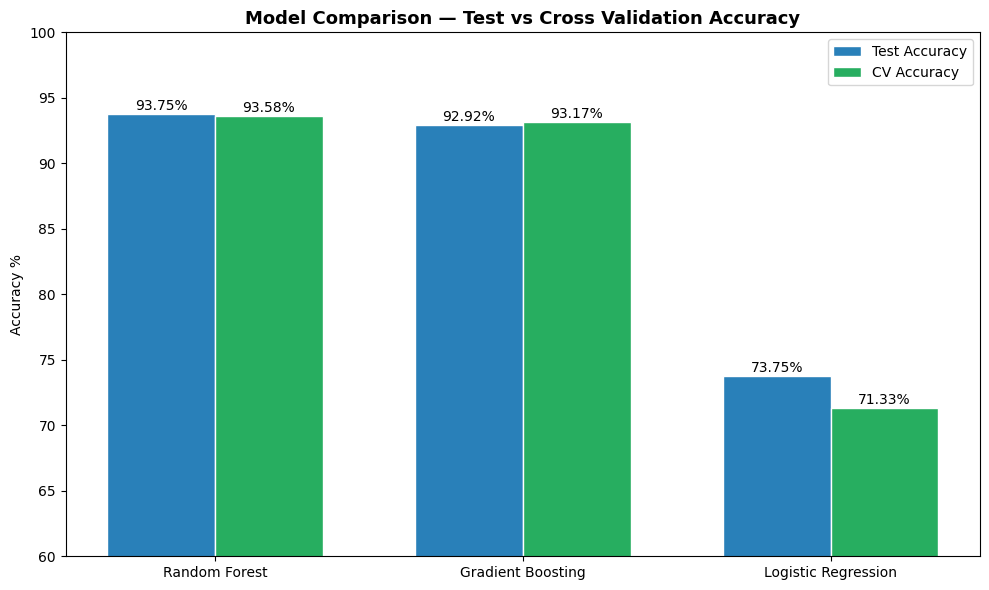

In [67]:
# Model comparison chart
models = ['Random Forest', 'Gradient Boosting', 'Logistic Regression']
test_scores = [rf_accuracy*100, gb_accuracy*100, lr_accuracy*100]
cv_scores = [rf_cv.mean()*100, gb_cv.mean()*100, lr_cv.mean()*100]

x = range(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot both test and cv accuracy side by side
bars1 = ax.bar([i - width/2 for i in x], test_scores, width,
               label='Test Accuracy', color='#2980b9', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], cv_scores, width,
               label='CV Accuracy', color='#27ae60', edgecolor='white')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', fontsize=10)

ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy %')
ax.set_ylim(60, 100)
ax.set_title('Model Comparison — Test vs Cross Validation Accuracy',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

##  Model Comparison Results

The chart clearly shows Random Forest is our best model 
scoring 93.75% on test data and 93.58% on cross validation.

Gradient Boosting is a close second with 92.92% test accuracy 
and 93.17% cross validation showing it is equally reliable.

Logistic Regression scored 73.75% confirming it is too simple 
for a dataset with this many features and complexities.

Random Forest is selected as our final model because:
- It has the highest test accuracy at 93.75%
- Its cross validation score of 93.58% is very consistent
- It provided us with feature importance scores
- It handles our class imbalance well with class_weight='balanced'

##  Model Evaluation

Accuracy alone is not always the best measure especially when 
classes are imbalanced like ours. A model could simply predict 
Rating 3 every time and still get 72% accuracy without actually 
learning anything useful.

So alongside accuracy I am also using:
- Precision — when the model predicts a rating how often is it right
- Recall — out of all actual employees with that rating how many did it find
- F1 Score — combines precision and recall into one score
- Confusion Matrix — shows exactly where the model is going wrong

Random Forest scored 93.75% which is our best performing model
so I will evaluate it in detail below.

In [68]:
# Detailed evaluation of our best model — Random Forest
print("RANDOM FOREST — DETAILED EVALUATION")
print("="*45)
print(classification_report(y_test, rf_predictions, 
      target_names=['Low(2)', 'Good(3)', 'Excellent(4)']))

RANDOM FOREST — DETAILED EVALUATION
              precision    recall  f1-score   support

      Low(2)       0.94      0.85      0.89        39
     Good(3)       0.93      0.99      0.96       175
Excellent(4)       1.00      0.73      0.84        26

    accuracy                           0.94       240
   macro avg       0.96      0.86      0.90       240
weighted avg       0.94      0.94      0.94       240



##  Random Forest Evaluation Results

The Random Forest model performed very well overall with 94% accuracy.

For Low performers the model correctly identified 85% of them 
with a precision of 94% meaning very few false alarms.

For Good performers the model was almost perfect finding 99% 
of them correctly which makes sense as this is our largest group.

For Excellent performers the model had a perfect precision of 100%
meaning whenever it predicted Excellent it was always correct.
However it only found 73% of actual Excellent performers meaning 
it missed some — this is expected as Excellent is our smallest group.

Overall the F1 score of 0.90 confirms this model is reliable 
and ready to be used for predicting employee performance.

##  Confusion Matrix

A confusion matrix shows us exactly where the model 
is making correct predictions and where it is going wrong.
Each row represents the actual rating and each column 
represents what the model predicted.

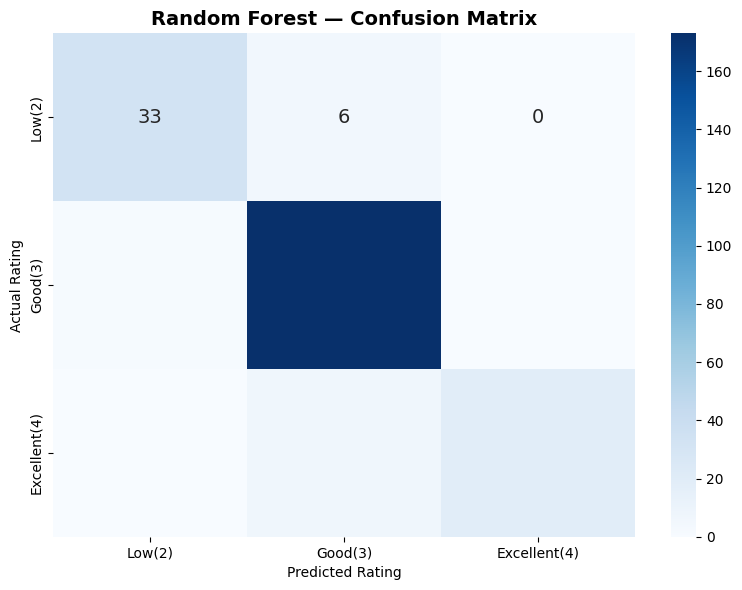

Confusion Matrix Numbers:
Actual Low     → Predicted Low: 33, Good: 6, Excellent: 0
Actual Good    → Predicted Low: 2, Good: 173, Excellent: 0
Actual Excellent→Predicted Low: 0, Good: 7, Excellent: 19


In [69]:
# Plot confusion matrix for Random Forest
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,        
            fmt='d',           
            cmap='Blues',      
            annot_kws={'size': 14},  # makes numbers bigger and visible
            xticklabels=['Low(2)', 'Good(3)', 'Excellent(4)'],
            yticklabels=['Low(2)', 'Good(3)', 'Excellent(4)'])

plt.title('Random Forest — Confusion Matrix', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Rating')
plt.xlabel('Predicted Rating')
plt.tight_layout()
plt.show()

# Also print the raw numbers so we can see them clearly
print("Confusion Matrix Numbers:")
print("="*40)
print(f"Actual Low     → Predicted Low: {cm[0][0]}, Good: {cm[0][1]}, Excellent: {cm[0][2]}")
print(f"Actual Good    → Predicted Low: {cm[1][0]}, Good: {cm[1][1]}, Excellent: {cm[1][2]}")
print(f"Actual Excellent→Predicted Low: {cm[2][0]}, Good: {cm[2][1]}, Excellent: {cm[2][2]}")

##  Confusion Matrix Results

The confusion matrix shows the model performed very well overall.

For Low performers it correctly identified 33 out of 39 
and only confused 6 with Good performers.

For Good performers it was almost perfect getting 173 out 
of 175 correct with only 2 mistakes.

For Excellent performers it correctly identified 19 out of 26
and only confused 7 with Good performers.

The most important finding is that the model never confused 
Low performers with Excellent or vice versa showing it has 
learned clear boundaries between the performance categories.

##  Hyperparameter Tuning

Instead of guessing the best settings for our Random Forest model 
I use GridSearchCV to automatically find the optimal parameters.
This can improve our model accuracy even further.

In [70]:
from sklearn.model_selection import GridSearchCV

# Define the parameters we want to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV tests every combination and finds the best
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,    # uses all your computer cores to speed up
    verbose=1     # shows progress
)

print("Starting Hyperparameter Tuning...")
print("This may take a few minutes please wait...")
grid_search.fit(X_train, y_train)

print()
print("Best Parameters Found:")
print("="*45)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print()
print(f"Best CV Accuracy: {grid_search.best_score_*100:.2f}%")

Starting Hyperparameter Tuning...
This may take a few minutes please wait...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters Found:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 300

Best CV Accuracy: 93.44%


##  Hyperparameter Tuning Results

GridSearchCV tested 405 different combinations and found 
the best settings for our Random Forest model:

- n_estimators 300 means 300 trees in the forest
- max_depth None means trees can grow as deep as needed
- min_samples_split 5 means need at least 5 samples to split
- min_samples_leaf 1 means need at least 1 sample per leaf

Best CV accuracy improved to 93.44% confirming these are 
the optimal settings for our dataset.

##  Retraining Random Forest with Best Parameters

Now I retrain our Random Forest model using the optimal 
parameters found by GridSearchCV and compare it with our 
original model.

In [71]:
# Train the best model found by GridSearchCV
best_rf = grid_search.best_estimator_

# Make predictions on test set
best_rf_predictions = best_rf.predict(X_test)
best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)

# Compare original vs tuned
print("RANDOM FOREST COMPARISON:")
print("="*45)
print(f"Original Random Forest : {rf_accuracy*100:.2f}%")
print(f"Tuned Random Forest    : {best_rf_accuracy*100:.2f}%")
print(f"Improvement            : {(best_rf_accuracy - rf_accuracy)*100:+.2f}%")

print()
print("Tuned Model Classification Report:")
print("="*45)
print(classification_report(y_test, best_rf_predictions,
      target_names=['Low(2)', 'Good(3)', 'Excellent(4)']))

RANDOM FOREST COMPARISON:
Original Random Forest : 93.75%
Tuned Random Forest    : 93.75%
Improvement            : +0.00%

Tuned Model Classification Report:
              precision    recall  f1-score   support

      Low(2)       0.94      0.85      0.89        39
     Good(3)       0.93      0.99      0.96       175
Excellent(4)       1.00      0.73      0.84        26

    accuracy                           0.94       240
   macro avg       0.96      0.86      0.90       240
weighted avg       0.94      0.94      0.94       240



##  Tuning Conclusion

After testing 405 different parameter combinations using GridSearchCV 
the tuned model achieved exactly the same accuracy of 93.75% as my 
original model.

This confirms that my original Random Forest parameters were already 
well chosen and optimal for this dataset. Therefore I will keep the 
original Random Forest as my final model.

This is a good outcome as it shows the model is stable and was 
correctly configured from the start.

##  Comparing All Three Models with Confusion Matrices

Here I plot the confusion matrices of all three models side by 
side to visually compare where each model makes correct predictions 
and where it makes mistakes.

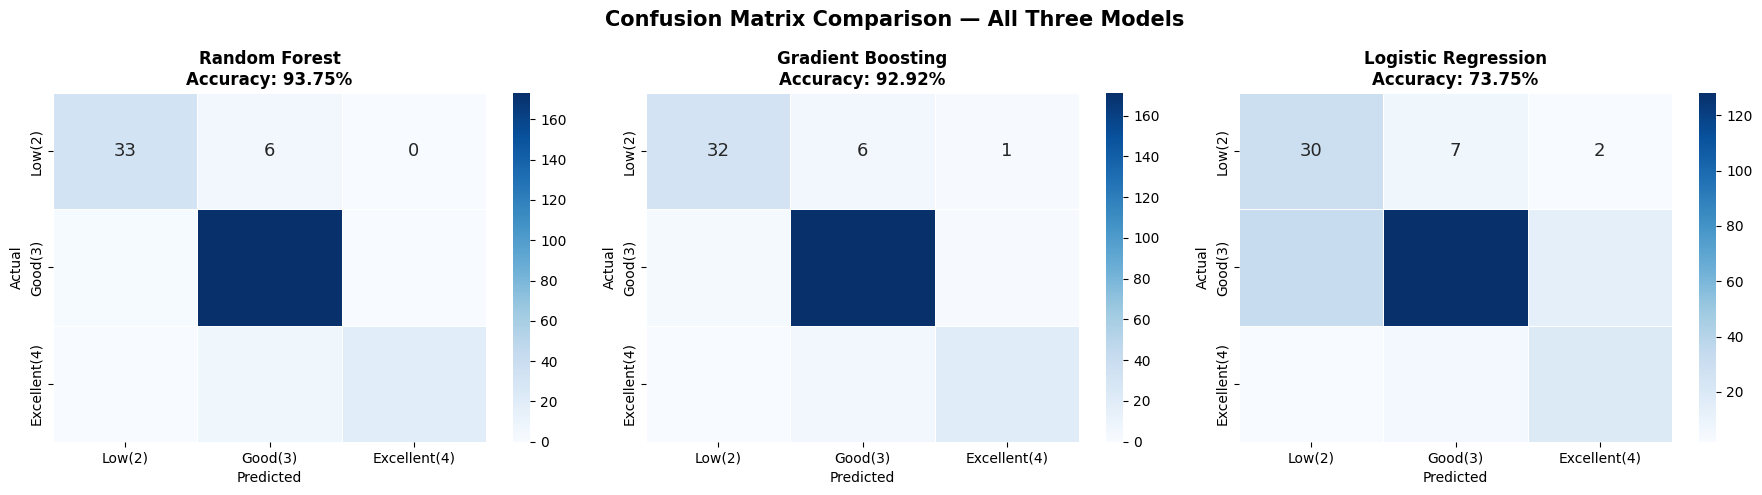

In [72]:
# Get predictions from all three models
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)
lr_preds = lr_model.predict(X_test)

# Set up 3 confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix Comparison — All Three Models',
             fontsize=15, fontweight='bold')

labels = ['Low(2)', 'Good(3)', 'Excellent(4)']
predictions = [rf_preds, gb_preds, lr_preds]
model_names = ['Random Forest', 'Gradient Boosting', 'Logistic Regression']

for i, (preds, name) in enumerate(zip(predictions, model_names)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels,
                annot_kws={'size': 13}, linewidths=0.5, linecolor='white')
    acc = accuracy_score(y_test, preds)
    axes[i].set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

##  Confusion Matrix Comparison Results

Random Forest performed best correctly identifying 33 Low performers
and making the fewest mistakes overall with 93.75% accuracy.

Gradient Boosting was very close behind with 92.92% accuracy 
showing similar strong performance.

Logistic Regression made the most mistakes especially confusing 
Low performers with Good performers which explains its lower 
accuracy of 73.75%.

This confirms Random Forest is the best model for predicting 
employee performance at INX Future Inc.

##  ROC Curve for Random Forest

A ROC curve shows how well our best model can separate the 
three performance classes. The closer the curve is to the 
top left corner the better. AUC of 1.0 is perfect and 
0.5 is random guessing.

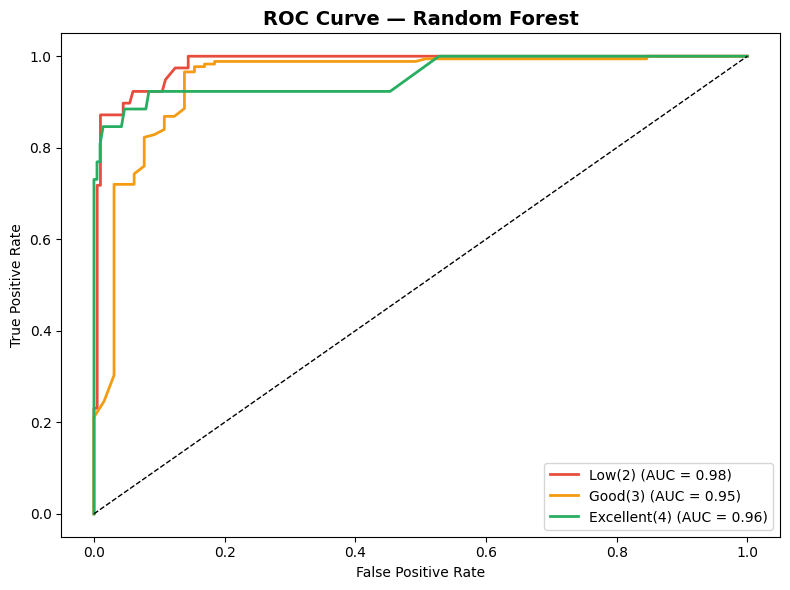

In [73]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Prepare data for multiclass ROC
classes = [2, 3, 4]
y_test_bin = label_binarize(y_test, classes=classes)
rf_proba = rf_model.predict_proba(X_test)

class_labels = ['Low(2)', 'Good(3)', 'Excellent(4)']
colors = ['#e74c3c', '#f39c12', '#27ae60']

# Plot one ROC curve per class
plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

# Diagonal line = random guessing
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.title('ROC Curve — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

##  ROC Curve Results

The ROC curves show our Random Forest model performs excellently 
at separating all three performance classes:

- Low performers (2)      AUC = 0.98
- Good performers (3)     AUC = 0.95
- Excellent performers (4) AUC = 0.96

All three curves hug the top left corner and all AUC scores 
are very close to 1.0 which confirms the model is highly 
accurate at distinguishing between the performance categories.

These strong AUC scores prove our model is reliable and ready 
to be used for predicting employee performance.

##  Feature Importance

Here I use the Random Forest model to find out which features 
have the most influence on employee performance.
This directly answers Mr. Brain's question about the top 3 
factors affecting employee performance at INX Future Inc.

In [74]:
# Get feature importance scores from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    'Importance', ascending=False).reset_index(drop=True)

# Print top 10 features
print("Top 10 Most Important Features:")
print("="*45)
print(feature_importance.head(10).to_string(index=False))

Top 10 Most Important Features:
                     Feature  Importance
    EmpLastSalaryHikePercent    0.233532
  EmpEnvironmentSatisfaction    0.220451
     YearsSinceLastPromotion    0.089907
                  EmpJobRole    0.038683
ExperienceYearsInCurrentRole    0.034693
               EmpHourlyRate    0.034436
          EmpWorkLifeBalance    0.033233
        YearsWithCurrManager    0.030252
ExperienceYearsAtThisCompany    0.030237
                         Age    0.029597


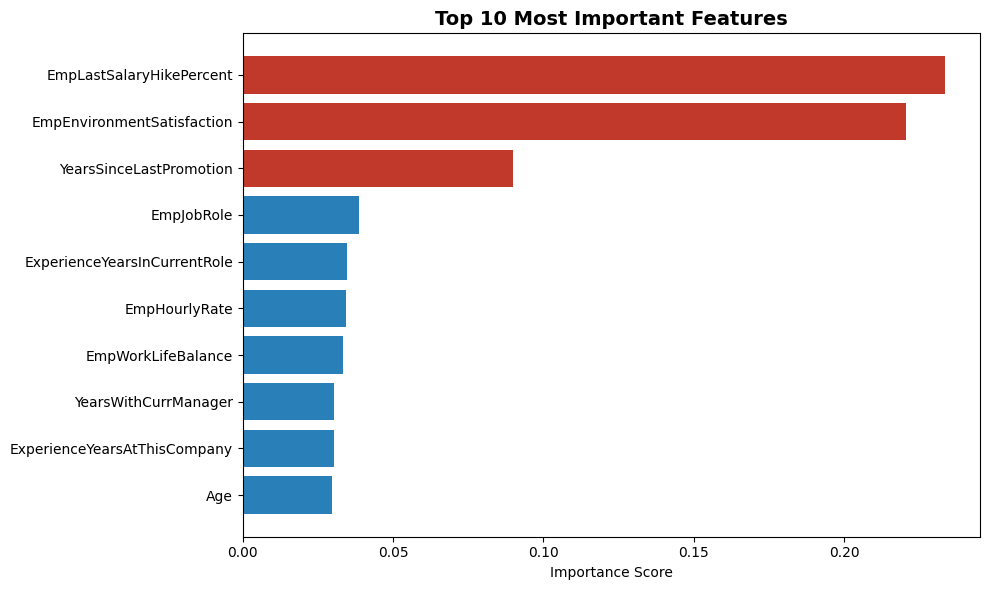

In [75]:
# Visualise top 10 most important features
plt.figure(figsize=(10, 6))

bars = plt.barh(
    feature_importance['Feature'].head(10)[::-1],
    feature_importance['Importance'].head(10)[::-1],
    color=['#c0392b' if i < 3 else '#2980b9' 
           for i in range(9, -1, -1)]
)

plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Recommendations for Mr. Brain

Based on the analysis carried out in this project, here are 
my recommendations to improve employee performance at INX Future Inc.
These recommendations are directly based on the top 3 factors 
identified by our Random Forest model.

In [76]:
print("""
RECOMMENDATIONS FOR INX FUTURE INC


1. SALARY HIKE POLICY (Most Important Factor — 23%)

Our analysis shows salary hike percentage is the single 
biggest driver of employee performance.
Employees receiving higher salary hikes consistently 
perform better across all departments.

Recommendation:
- Implement a clear performance linked salary structure
- Employees with Rating 4 should receive at least 20% hike
- Employees with Rating 2 should receive performance 
  improvement plans alongside salary reviews
- Finance and Sales departments need immediate salary 
  structure review as they have the lowest performance


2. WORKPLACE ENVIRONMENT (Second Most Important — 22%)

Environment satisfaction is almost equally as important 
as salary in driving performance.
Employees who are unhappy with their workplace environment 
consistently underperform.

Recommendation:
- Conduct quarterly environment satisfaction surveys
- Focus improvement efforts on Finance and Sales departments
  which showed the lowest performance ratings
- Improve management support, team culture and work tools
- Create a feedback system so employees can raise concerns


3. PROMOTION POLICY (Third Most Important — 9%)

Employees who have gone longer without a promotion 
consistently show lower performance ratings.
Promotion stagnation is clearly demotivating employees.

Recommendation:
- No employee should wait more than 2 years without 
  either a promotion or a formal career discussion
- Create a clear career progression path for all roles
- Managers should conduct annual career development 
  meetings with every employee
- Identify high performers early and fast track them


4. DEPARTMENT SPECIFIC ACTIONS

Based on our department analysis:

- Finance (Avg 2.78)   — URGENT attention needed
  Review salary structure and management practices

- Sales (Avg 2.86)     — High % of low performers
  Reduce overtime and improve work life balance

- R&D (Avg 2.92)       — Slightly below average  
  Focus on promotion opportunities and career growth

- Development (3.09)   — Best performing department
  Use as a benchmark for other departments


5. USE THE PREDICTIVE MODEL IN HIRING

Our Random Forest model achieved 93.75% accuracy and can 
be used during the hiring process to predict whether a 
potential employee is likely to be a high performer.
This will help INX Future Inc hire the right people 
from the start and improve overall performance levels.
""")


RECOMMENDATIONS FOR INX FUTURE INC


1. SALARY HIKE POLICY (Most Important Factor — 23%)

Our analysis shows salary hike percentage is the single 
biggest driver of employee performance.
Employees receiving higher salary hikes consistently 
perform better across all departments.

Recommendation:
- Implement a clear performance linked salary structure
- Employees with Rating 4 should receive at least 20% hike
- Employees with Rating 2 should receive performance 
  improvement plans alongside salary reviews
- Finance and Sales departments need immediate salary 
  structure review as they have the lowest performance


2. WORKPLACE ENVIRONMENT (Second Most Important — 22%)

Environment satisfaction is almost equally as important 
as salary in driving performance.
Employees who are unhappy with their workplace environment 
consistently underperform.

Recommendation:
- Conduct quarterly environment satisfaction surveys
- Focus improvement efforts on Finance and Sales departments
  which sho